# The hypoexponential distribution to describe the inter-arrival time
If two or more exponential distributions are summed (convolution of probablitiy distributions) and their rate parameters are different, the resulting distribution is the hypoexponential distribution. 

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")
import src.distributions as d
import src.fluorophore_systems as fs
import src.figures as fi

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
rng = np.random.default_rng(100)

a, b, c = 4, 10, 16.7

exp1 = rng.exponential(1/a, size=1000000)
exp2 = rng.exponential(1/b, size=1000000)
exp3 = rng.exponential(1/c, size=1000000)

hypo_2_parameters = exp2 + exp3
hypo_3_parameters = exp1 + exp2 + exp3

## The two-parameter case

In [10]:
cdf_2_parameters = d.hypoexponential_distribution_two_parameters_cdf(b, c, np.linspace(0, 1, 200))
pdf_2_parameters = d.hypoexponential_distribution_two_parameters_pdf(b, c, np.linspace(0, 1, 200))

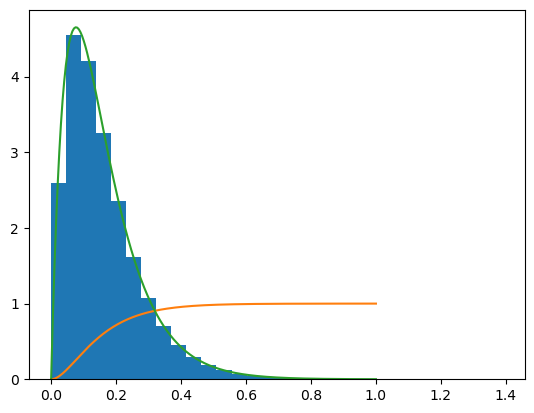

In [11]:
plt.hist(hypo_2_parameters, density=True, bins=30)
plt.plot(np.linspace(0, 1, 200), cdf_2_parameters)
plt.plot(np.linspace(0, 1, 200), pdf_2_parameters)

#### Check CDF

In [12]:
print(len(np.where(hypo_2_parameters<0.2512)[0])/len(hypo_2_parameters))
print(cdf_2_parameters[50])

0.819851
0.820425965564013


-------------------------------------------

## The three-parameter case

In [13]:
cdf_3_parameters = d.hypoexponential_distribution_three_parameters_cdf(a, b, c, np.linspace(0, 2, 200))
pdf_3_parameters = d.hypoexponential_distribution_three_parameters_pdf(a, b, c, np.linspace(0, 2, 200))

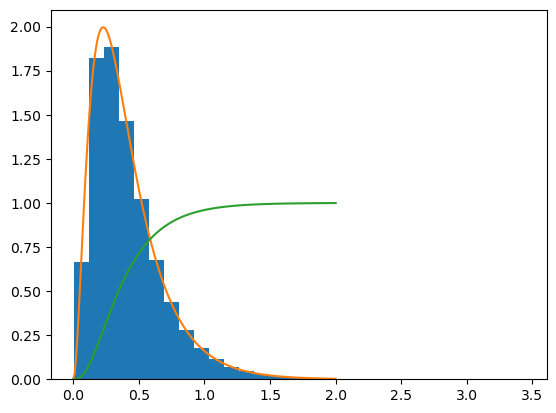

In [14]:
plt.hist(hypo_3_parameters, density=True, bins=30)
plt.plot(np.linspace(0, 2, 200), pdf_3_parameters)
plt.plot(np.linspace(0, 2, 200), cdf_3_parameters);

#### Check CDF

In [15]:
print(len(np.where(hypo_3_parameters<0.502)[0])/len(hypo_3_parameters))
print(cdf_3_parameters[50])

0.71624
0.7171770524225795


## Sampling from the distribution
The inverse function of the cdf has not analytic solution. Hence, the strategy will be to use rejection sampling instead of inverse transform sampling.

### Two-parameter case

In [17]:
samples = d.rejection_sampling(d.hypoexponential_distribution_two_parameters_pdf, 
                               x_min=0, x_max=1, y_min=0, y_max=5, batch=1000, size=10000, 
                               parameters=[10, 16.7])

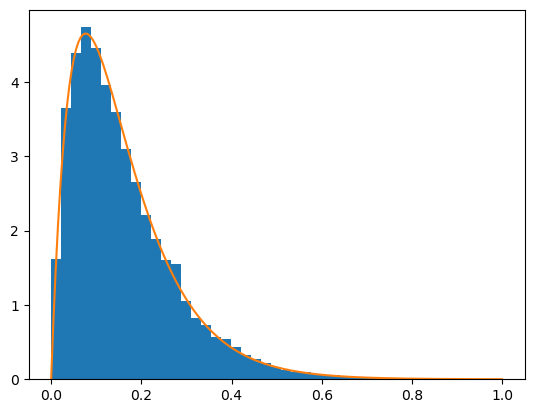

In [18]:
plt.hist(samples, density=True, bins=40);
plt.plot(np.linspace(0, 1, 200), pdf_2_parameters);

### Application to fluorescence intensity distributions

#### Time between events

In [44]:
rate_dict = dict(k_S0_S1=[7e6, "excitation"],
                 k_S1_S0=[1e9, "emission"])

system = fs.GeneralModel(number=1,  distances=1, rates=rate_dict)
system.simulate(n_steps=1000000, seed=99)
system.process()
emission_after_time = np.add.reduceat(system.time_step_series, np.arange(0, len(system.time_step_series), 2))

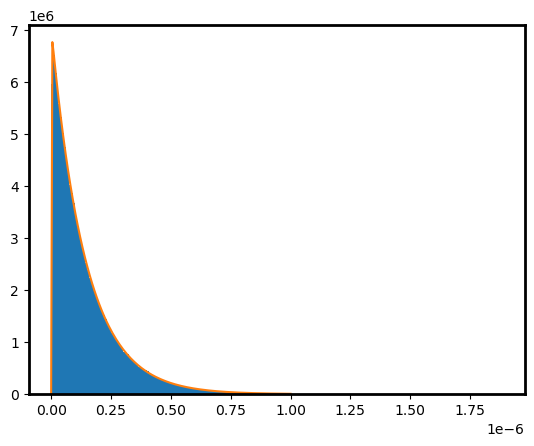

In [55]:
plt.hist(emission_after_time, bins=250, density=True);
plt.plot(np.linspace(0, 1e-6, 200), d.hypoexponential_distribution_two_parameters_pdf(7e6, 1e9, np.linspace(0, 1e-6, 200)))

#### Event count per time

In [22]:
rate_dict = dict(k_tS0_tS1=[7e6, "excitation"],
                 k_tS1_tS0=[1e9, "emission"],
                 k_tS1_tT1=[1e6, "intersystem crossing"],
                 k_tT1_tS0=[5e5, "triplet deexcitation"],
                 k_tS1_Cis=[2e7, "isomerization"],
                 k_Cis_tS0=[1e5, "backisomerization"])

system = fs.Cy5CisModel(number=1,  distances=1, rates=rate_dict)
system.simulate(n_steps=10000000, seed=99)
system.process()
system.emitters(resample="0.1ms", photon_collection=1)

##### Check for sampling bounds

Text(0.5, 1.0, 'Cis/tS0/tS1')

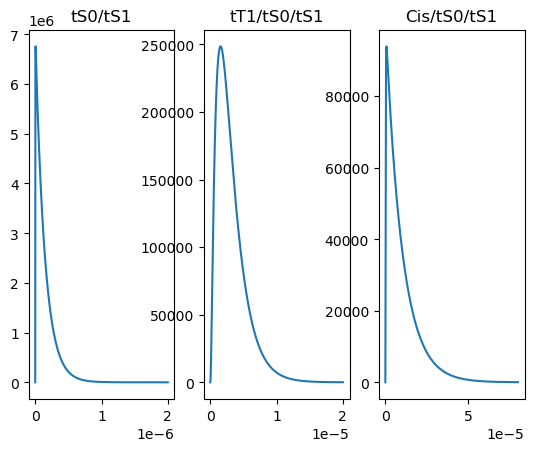

In [34]:
pdf1 = d.hypoexponential_distribution_two_parameters_pdf(7e6, 1e9, np.linspace(0, 2e-6, 10000))
pdf2 = d.hypoexponential_distribution_three_parameters_pdf(7e6, 1e6, 5e5, np.linspace(0, 2e-5, 10000))
pdf3 = d.hypoexponential_distribution_three_parameters_pdf(7e6, 2e7, 1e5, np.linspace(0, 8e-5, 10000))
fig, ax = plt.subplots(ncols=3, nrows=1)
ax[0].plot(np.linspace(0, 2e-6, 10000), pdf1)
ax[0].set_title('tS0/tS1')
ax[1].plot(np.linspace(0, 2e-5, 10000), pdf2)
ax[1].set_title('tT1/tS0/tS1')
ax[2].plot(np.linspace(0, 8e-5, 10000), pdf3)
ax[2].set_title('Cis/tS0/tS1')

In [35]:
steps = 10000000
param_1 = [7e6, 1e9]
param_2 = [7e6, 1e6, 5e5]
param_3 = [7e6, 2e7, 1e5]
ratio_1 = 1e9/(1e9 + 1e6 + 2e7)
ratio_2 = 1e6/(1e9 + 1e6 + 2e7)

random_numbers = np.random.uniform(0, 1, steps)
events = np.zeros(steps)
time_steps = []
for i in range(steps):
    if random_numbers[i] < ratio_1:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_two_parameters_pdf,
                                       x_min=0, x_max=2e-6,
                                       y_min=0, y_max=2e7, batch=10, size=1, parameters=param_1)
        events[i] = 1
        time_steps.append(time_step)
    elif random_numbers[i] < ratio_1 + ratio_2:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_three_parameters_pdf,
                                       x_min=0, x_max=2e-5,
                                       y_min=0, y_max=3e5, batch=10, size=1, parameters=param_2)
        time_steps.append(time_step)
    else:
        time_step = d.rejection_sampling(d.hypoexponential_distribution_three_parameters_pdf,
                                       x_min=0, x_max=8e-5,
                                       y_min=0, y_max=1e5, batch=10, size=1, parameters=param_3)
        time_steps.append(time_step)

In [38]:
time_series = np.cumsum(time_steps)
mask = np.where(events==1)
events_at = time_series[mask]
events_at = np.insert(events_at, 0, 0)
time_deltas = pd.to_timedelta(events_at, unit="s")

events = np.ones(len(events_at))
events[0] = 0
series = pd.Series(events, index=time_deltas)
series = series.resample("0.1ms").sum()
time_deltas = series.index
in_seconds = time_deltas / np.timedelta64(1, "s")
series.index = in_seconds

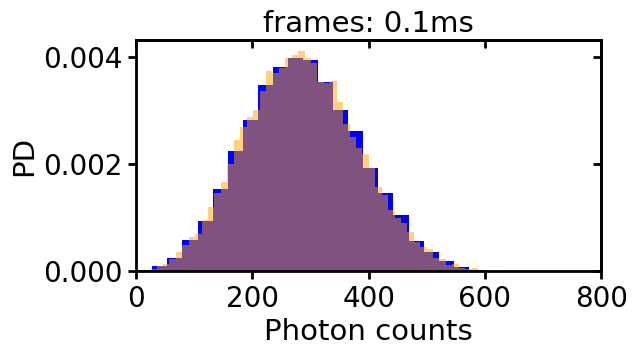

In [39]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=26,
                                                      xlim=[0, 800])
ax[0].hist(series[series != 0], density=True, bins=60, alpha=0.5, color='orange');